In [1]:
# ================================================================
# 1️⃣ Importar librerías
# ================================================================
import pandas as pd
import numpy as np
import urllib
from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as snsimport osfrom dotenv import load_dotenvload_dotenv()

In [2]:
# ================================================================
# 2️⃣ Conexión a SQL Server y carga de datos
# ================================================================
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={os.getenv('DB_SERVER')};"
    "DATABASE=B2B;"
    f"UID={os.getenv('DB_USER')};"
    f"PWD={os.getenv('DB_PASSWORD')};"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

query = """
SELECT 
    Codigo_Cliente,
    Nombre_Cliente,
    Numero_Documento,
    Fecha_Documento,
    Valor_Subtotal
FROM B2B.dbo.Ventas_B2BMovinova
WHERE 
    Tipo_Cliente = 'HOTEL'
    AND Fecha_Documento >= '2024-10-01'
    AND Fecha_Documento <= '2025-09-30'
"""

df_hoteles = pd.read_sql(query, engine)
df_hoteles['Fecha_Documento'] = pd.to_datetime(df_hoteles['Fecha_Documento'], errors='coerce')

print("Dimensiones (filas, columnas):", df_hoteles.shape)
print("Rango de fechas:", df_hoteles['Fecha_Documento'].min(), "→", df_hoteles['Fecha_Documento'].max())
print("Clientes únicos:", df_hoteles['Codigo_Cliente'].nunique())
print("Facturas únicas:", df_hoteles['Numero_Documento'].nunique())


Dimensiones (filas, columnas): (4632, 5)
Rango de fechas: 2024-10-03 00:00:00 → 2025-09-30 00:00:00
Clientes únicos: 244
Facturas únicas: 1410


In [3]:
# ================================================================
# 3️⃣ Calcular tabla RFM
# ================================================================
fecha_ref = df_hoteles["Fecha_Documento"].max()

# Crear una columna auxiliar con el año-mes de cada compra
df_hoteles["AñoMes"] = df_hoteles["Fecha_Documento"].dt.to_period("M")

# Calcular RFM
rfm = df_hoteles.groupby("Codigo_Cliente").agg({
    "Fecha_Documento": lambda x: (fecha_ref - x.max()).days,       # Recency
    "AñoMes": "nunique",                                           # Frequency mensual
    "Valor_Subtotal": "sum"                                        # Monetary
}).reset_index()

rfm.columns = ["Codigo_Cliente", "Recency", "Frequency", "Monetary"]

print("✅ Tabla RFM creada correctamente (frecuencia mensual)")
print(f"Clientes únicos: {rfm.shape[0]}")
print("\nEstadísticas básicas:")
print(rfm.describe())

✅ Tabla RFM creada correctamente (frecuencia mensual)
Clientes únicos: 244

Estadísticas básicas:
          Recency   Frequency      Monetary
count  244.000000  244.000000  2.440000e+02
mean    99.672131    4.004098  1.220383e+07
std     97.848959    3.359769  3.469674e+07
min      0.000000    1.000000  2.346900e+04
25%     22.000000    1.000000  7.937860e+05
50%     61.000000    3.000000  2.491673e+06
75%    161.000000    6.000000  8.576572e+06
max    355.000000   12.000000  3.305660e+08


Clientes totales: 244

Recency (días desde última compra) percentiles:
  p  0: 0
  p  1: 1
  p  5: 4
  p 10: 9
  p 25: 22
  p 50: 61
  p 75: 161
  p 90: 272
  p 95: 306
  p 97: 313
  p 99: 340
  p100: 355
  mean: 100  std: 98  min: 0  max: 355

Frequency (meses con compra) percentiles:
  p  0: 1
  p  1: 1
  p  5: 1
  p 10: 1
  p 25: 1
  p 50: 3
  p 75: 6
  p 90: 9
  p 95: 11
  p 97: 12
  p 99: 12
  p100: 12
  mean: 4  std: 3  min: 1  max: 12

Monetary ($ total gastado) percentiles:
  p  0: 23,469
  p  1: 58,787
  p  5: 243,862
  p 10: 327,990
  p 25: 793,786
  p 50: 2,491,673
  p 75: 8,576,572
  p 90: 30,223,016
  p 95: 49,700,098
  p 97: 75,472,214
  p 99: 191,033,992
  p100: 330,565,989
  mean: 12,203,832  std: 34,696,740  min: 23,469  max: 330,565,989


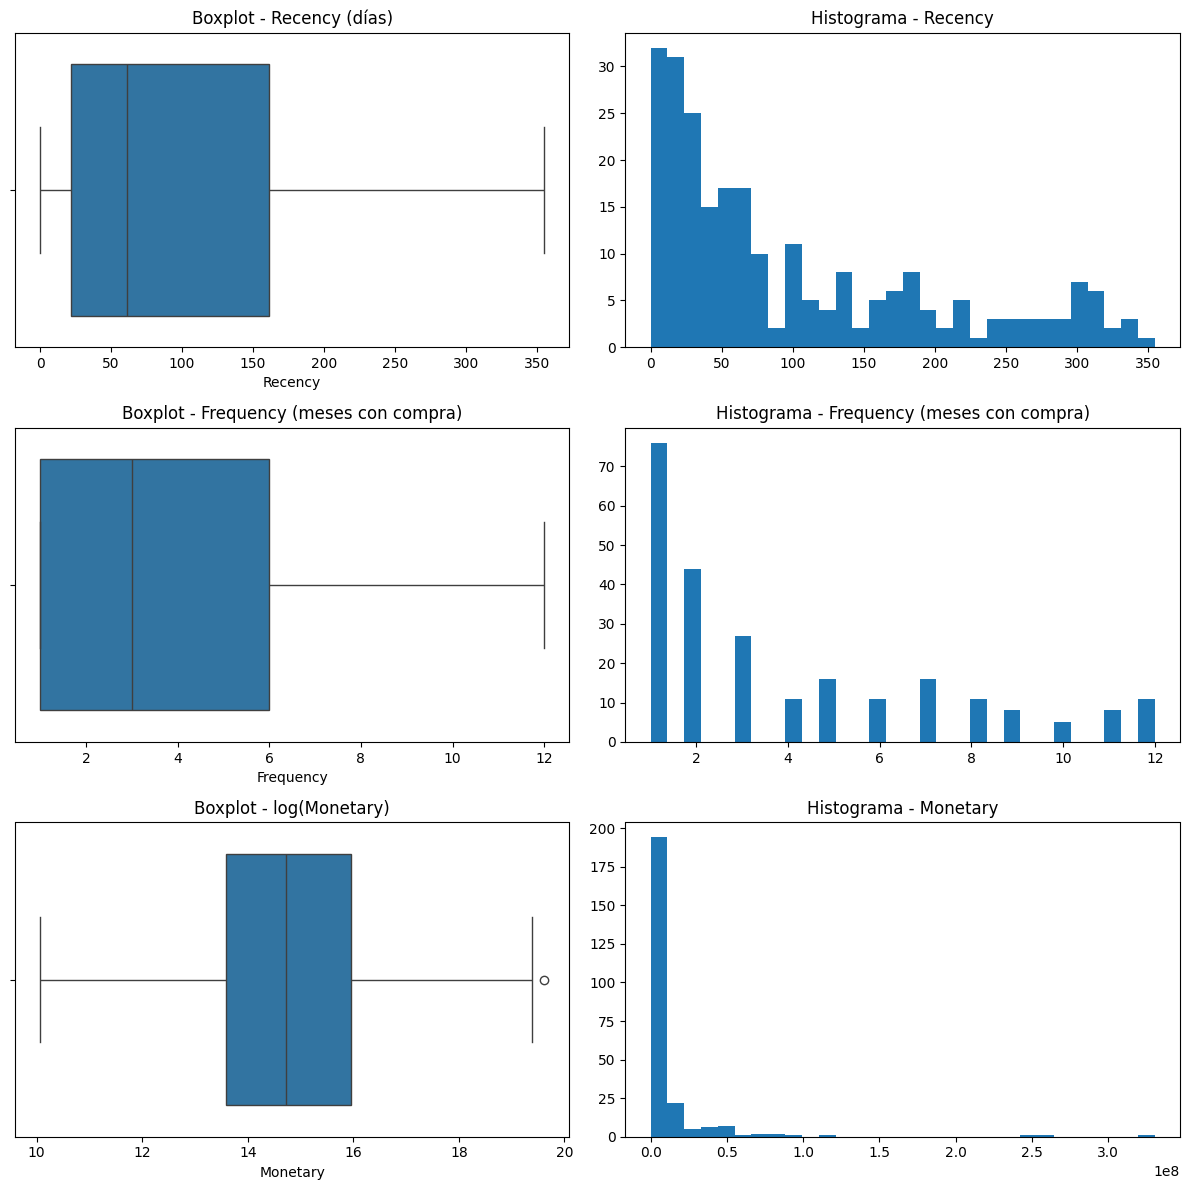

In [4]:
# ================================================================
# 4️⃣ Análisis de distribución y percentiles
# ================================================================
def print_percentiles(s, name):
    """Imprime percentiles, media y dispersión de una variable."""
    p = [0, 1, 5, 10, 25, 50, 75, 90, 95, 97, 99, 100]
    vals = np.percentile(s, p)
    print(f"\n{name} percentiles:")
    for pi, vi in zip(p, vals):
        print(f"  p{pi:>3}: {vi:,.0f}")
    print(f"  mean: {s.mean():,.0f}  std: {s.std():,.0f}  min: {s.min():,.0f}  max: {s.max():,.0f}")

# Resumen general de clientes
print("Clientes totales:", rfm.shape[0])
print_percentiles(rfm['Recency'], "Recency (días desde última compra)")
print_percentiles(rfm['Frequency'], "Frequency (meses con compra)")
print_percentiles(rfm['Monetary'], "Monetary ($ total gastado)")

# ==========================
# Boxplots e histogramas
# ==========================
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

sns.boxplot(x=rfm['Recency'], ax=axes[0, 0])
axes[0, 0].set_title('Boxplot - Recency (días)')
axes[0, 1].hist(rfm['Recency'], bins=30)
axes[0, 1].set_title('Histograma - Recency')

sns.boxplot(x=rfm['Frequency'], ax=axes[1, 0])
axes[1, 0].set_title('Boxplot - Frequency (meses con compra)')
axes[1, 1].hist(rfm['Frequency'], bins=30)
axes[1, 1].set_title('Histograma - Frequency (meses con compra)')

sns.boxplot(x=np.log1p(rfm['Monetary']), ax=axes[2, 0])
axes[2, 0].set_title('Boxplot - log(Monetary)')
axes[2, 1].hist(rfm['Monetary'], bins=30)
axes[2, 1].set_title('Histograma - Monetary')

plt.tight_layout()
plt.show()

In [5]:
# ================================================================
# 5️⃣ Filtrar outliers usando percentil 99
# ================================================================
percentiles = {
    #'Recency': rfm['Recency'].quantile(0.99),
    'Frequency': rfm['Frequency'].quantile(0.99),
    'Monetary': rfm['Monetary'].quantile(0.99)
}

rfm_filtered = rfm[
    #(rfm['Recency'] <= percentiles['Recency']) &
    (rfm['Frequency'] <= percentiles['Frequency']) &
    (rfm['Monetary'] <= percentiles['Monetary'])
]

print("Clientes totales:", len(rfm))
print("Clientes sin outliers:", len(rfm_filtered))
print("Outliers detectados:", len(rfm) - len(rfm_filtered))


Clientes totales: 244
Clientes sin outliers: 241
Outliers detectados: 3


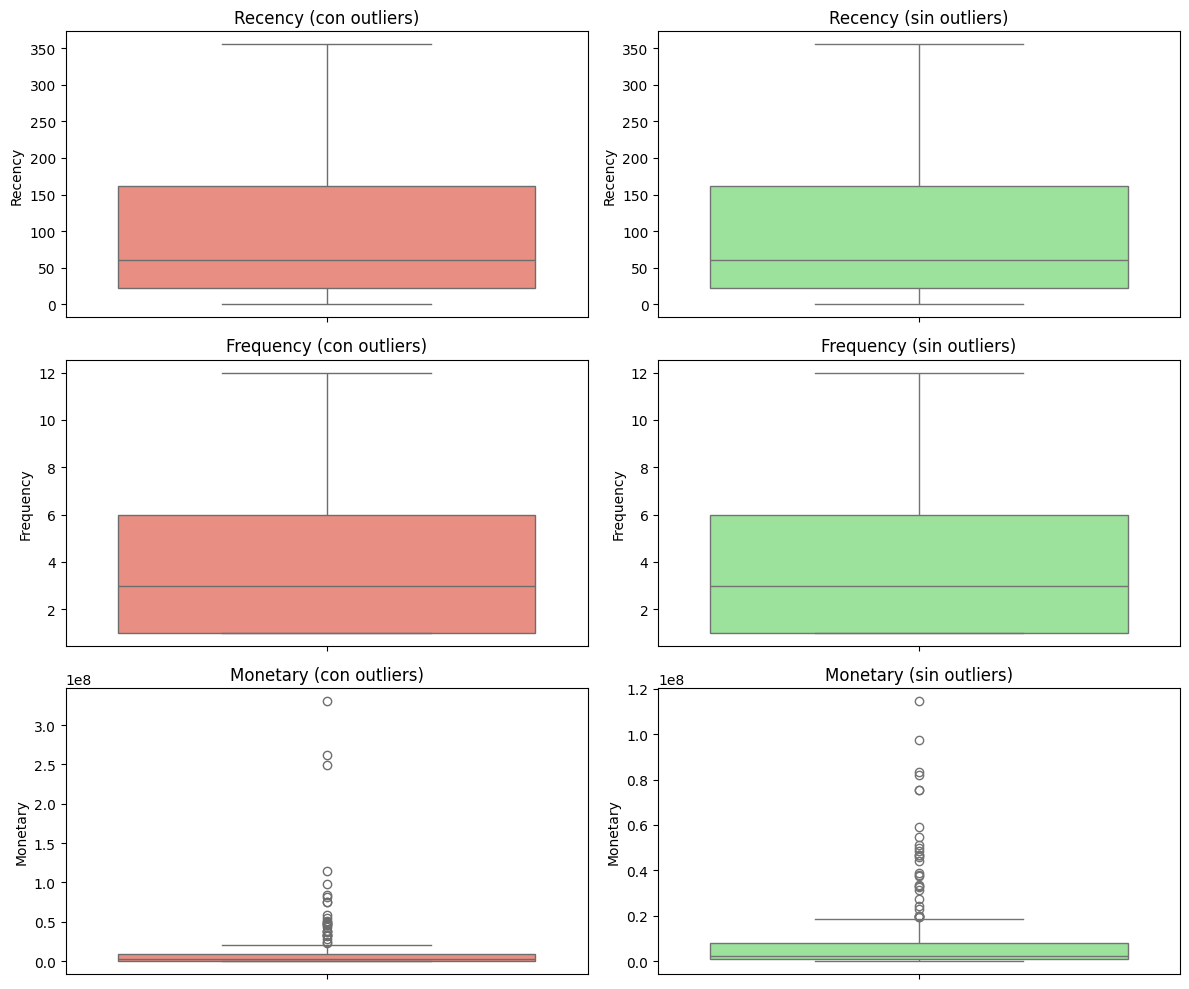

In [6]:
# ================================================================
# 6️⃣ Comparación visual antes y después de eliminar outliers
# ================================================================
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
features = ['Recency', 'Frequency', 'Monetary']

for i, col in enumerate(features):
    sns.boxplot(data=rfm, y=col, ax=axes[i, 0], color='salmon')
    axes[i, 0].set_title(f"{col} (con outliers)")

    sns.boxplot(data=rfm_filtered, y=col, ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f"{col} (sin outliers)")

plt.tight_layout()
plt.show()

In [7]:
# ================================================================
# 7️⃣ Escalado de variables RFM
# ================================================================

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_filtered[['Recency', 'Frequency', 'Monetary']])

# Convertimos a DataFrame escalado
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("Dimensiones del dataset escalado:", rfm_scaled.shape)

Dimensiones del dataset escalado: (241, 3)


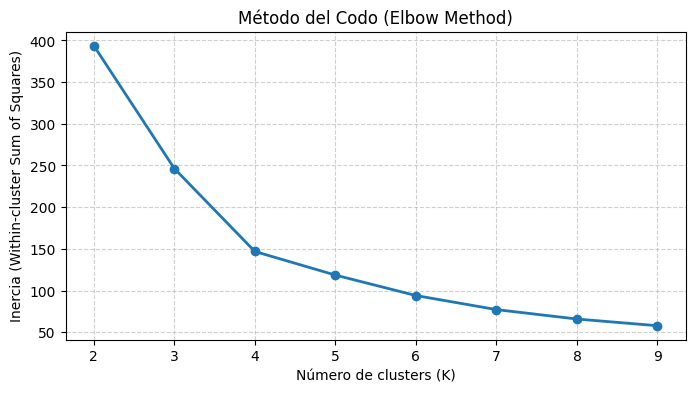

In [8]:
# ================================================================
# 8️⃣ Método del codo (Elbow Method)
# ================================================================

inertia = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'o-', linewidth=2)
plt.title("Método del Codo (Elbow Method)")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia (Within-cluster Sum of Squares)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [10]:
# ================================================================
# 9️⃣ Aplicar K-Means definitivo (K=4)
# ================================================================

# Entrenar el modelo con el número óptimo de clusters (K=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm_filtered = rfm_filtered.copy()
rfm_filtered['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Promedios por cluster
rfm_clusters = rfm_filtered.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Codigo_Cliente': 'count'
}).rename(columns={'Codigo_Cliente': 'NumClientes'}).reset_index()

rfm_clusters[['Recency', 'Frequency', 'Monetary']] = rfm_clusters[['Recency', 'Frequency', 'Monetary']].round(1)

rfm_clusters = rfm_clusters.sort_values('Monetary', ascending=False).reset_index(drop=True)

rfm_clusters


,Cluster,Recency,Frequency,Monetary,NumClientes
0,1,21.2,9.4,60223289.0,18
1,3,24.6,7.6,11588638.4,60
2,0,67.0,2.3,2408964.0,98
3,2,243.4,1.4,1855234.2,65


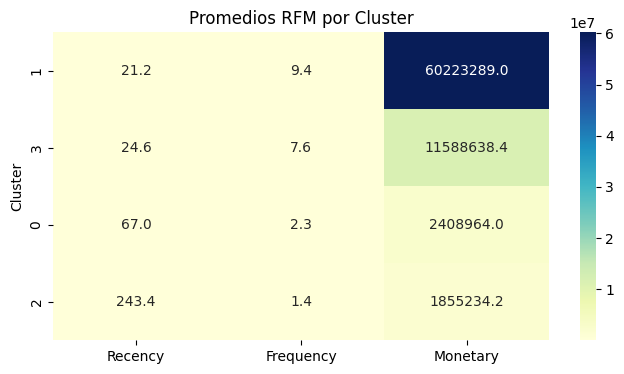

In [11]:
# ================================================================
# 🔍 Visualización de promedios por cluster
# ================================================================
plt.figure(figsize=(8, 4))
sns.heatmap(rfm_clusters.set_index('Cluster')[['Recency', 'Frequency', 'Monetary']], 
            annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Promedios RFM por Cluster")
plt.show()


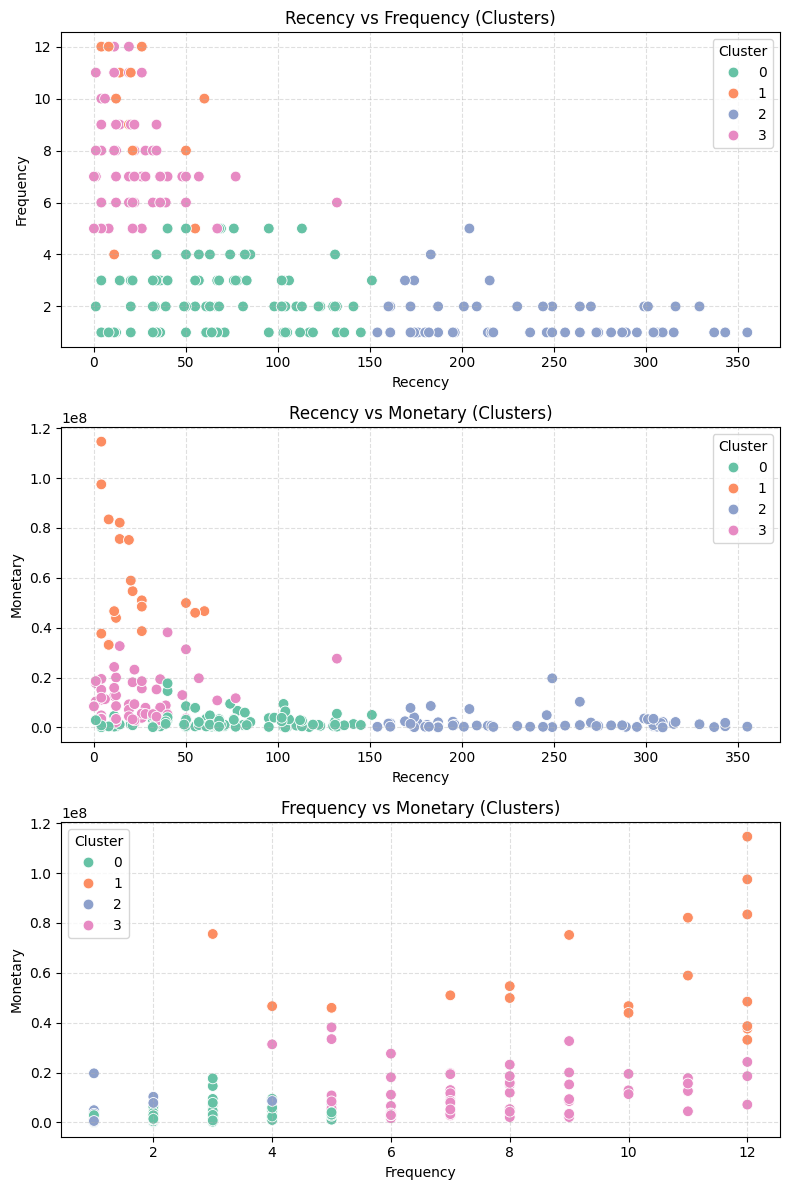

In [13]:
# ================================================================
# 🔟 Visualización de clusters RFM (sin outliers)
# ================================================================
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

sns.scatterplot(
    data=rfm_filtered, x='Recency', y='Frequency',
    hue='Cluster', palette='Set2', s=60, ax=axes[0]
)
axes[0].set_title('Recency vs Frequency (Clusters)')

sns.scatterplot(
    data=rfm_filtered, x='Recency', y='Monetary',
    hue='Cluster', palette='Set2', s=60, ax=axes[1]
)
axes[1].set_title('Recency vs Monetary (Clusters)')

sns.scatterplot(
    data=rfm_filtered, x='Frequency', y='Monetary',
    hue='Cluster', palette='Set2', s=60, ax=axes[2]
)
axes[2].set_title('Frequency vs Monetary (Clusters)')

for ax in axes:
    ax.legend(title='Cluster')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [14]:
# ================================================================
# Asignar segmento B2B (BRONCE, PLATA, ORO, DIAMANTE)
# ================================================================

segment_map = {
    1: 'DIAMANTE',
    3: 'ORO',
    0: 'PLATA',
    2: 'BRONCE'
}

rfm_filtered['Segmento'] = rfm_filtered['Cluster'].map(segment_map)

# Verificar distribución
rfm_filtered['Segmento'].value_counts()


Segmento
PLATA       98
BRONCE      65
ORO         60
DIAMANTE    18
Name: count, dtype: int64

🔹 Promedios de clusters con outliers incluidos:


,Cluster_full,Recency,Frequency,Monetary,NumClientes
0,0,63.773585,2.452830,3.987468e+06,106
1,1,243.369231,1.446154,1.855234e+06,65
2,2,24.333333,11.333333,2.805762e+08,3
3,3,23.828571,8.414286,2.275349e+07,70


🔹 Comparativo de promedios con vs sin outliers:


,Cluster_full,Recency_full,Frequency_full,Monetary_full,Recency_filtered,Frequency_filtered,Monetary_filtered
0,0,63.773585,2.452830,3.987468e+06,67.0,2.3,2408964.0
1,1,243.369231,1.446154,1.855234e+06,21.2,9.4,60223289.0
2,2,24.333333,11.333333,2.805762e+08,243.4,1.4,1855234.2
3,3,23.828571,8.414286,2.275349e+07,24.6,7.6,11588638.4


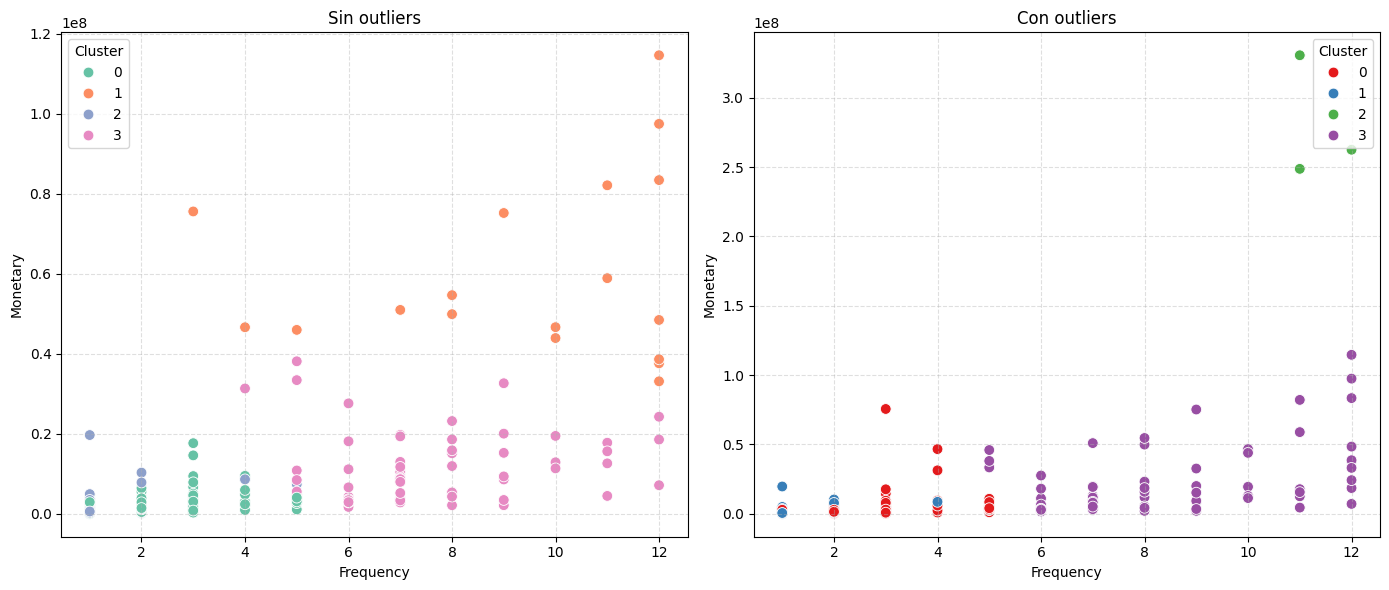

In [17]:
# ================================================================
# 9️⃣ Reentrenar KMeans incluyendo los outliers (comparativo)
# ================================================================

# Escalar nuevamente los datos completos (incluyendo outliers)
rfm_scaled_full = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Entrenar KMeans con K=4 en el dataset completo
kmeans_full = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster_full'] = kmeans_full.fit_predict(rfm_scaled_full)

# Perfil de clusters con outliers incluidos
rfm_clusters_full = (
    rfm.groupby('Cluster_full')
       .agg({
           'Recency': 'mean',
           'Frequency': 'mean',
           'Monetary': 'mean',
           'Codigo_Cliente': 'count'
       })
       .rename(columns={'Codigo_Cliente': 'NumClientes'})
       .reset_index()
)

print("🔹 Promedios de clusters con outliers incluidos:")
display(rfm_clusters_full)

# ================================================================
# 🔸 Comparación entre clusters con y sin outliers
# ================================================================
comparison = rfm_clusters_full.merge(
    rfm_clusters,
    how='outer',
    left_on='Cluster_full',
    right_on='Cluster',
    suffixes=('_full', '_filtered')
)

print("🔹 Comparativo de promedios con vs sin outliers:")
display(
    comparison[[
        'Cluster_full',
        'Recency_full', 'Frequency_full', 'Monetary_full',
        'Recency_filtered', 'Frequency_filtered', 'Monetary_filtered'
    ]]
)

# ================================================================
# 🔹 Visualización comparativa
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=rfm_filtered, x='Frequency', y='Monetary',
    hue='Cluster', palette='Set2', ax=axes[0], s=60
)
axes[0].set_title('Sin outliers')

sns.scatterplot(
    data=rfm, x='Frequency', y='Monetary',
    hue='Cluster_full', palette='Set1', ax=axes[1], s=60
)
axes[1].set_title('Con outliers')

for ax in axes:
    ax.legend(title='Cluster')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


In [62]:
# # Detectar los clientes que fueron excluidos por el filtro
# clientes_outliers = rfm[~rfm['Codigo_Cliente'].isin(rfm_filtered['Codigo_Cliente'])].copy()
# clientes_outliers['Segmento'] = 'DIAMANTE'

# # Unir con los clusters ya segmentados
# rfm_final = pd.concat([rfm_filtered, clientes_outliers], ignore_index=True)

# # Asegurar tipos y columnas consistentes
# rfm_final = rfm_final[['Codigo_Cliente', 'Recency', 'Frequency', 'Monetary', 'Segmento']]
# rfm_final['Segmento'] = rfm_final['Segmento'].astype(str)

# print(rfm_final['Segmento'].value_counts())
# rfm_final


### Interpretación de los segmentos B2B (K-Means RFM)

El análisis RFM permitió clasificar a los clientes **B2B (hoteles)** en cuatro segmentos con comportamientos claramente diferenciados según su **recencia**, **frecuencia** y **valor monetario**.

| Segmento | Características Principales |
|-----------|-----------------------------|
| 💎 **DIAMANTE** | Compras frecuentes, montos altos y recientes. Clientes de mayor valor. |
| 🥇 **ORO** | Buena frecuencia y gasto, pero con una recencia algo mayor. |
| 🥈 **PLATA** | Compran ocasionalmente y con montos moderados. |
| 🥉 **BRONCE** | Baja frecuencia y gasto, con mayor tiempo desde la última compra. |

---

### Resumen general de resultados

- Se aplicó **K-Means con K=4** luego de filtrar outliers (percentil 99) y escalar las variables.    
- Los **grupos se diferencian principalmente** por la **frecuencia de compra y el valor monetario**, mientras que la recencia ayuda a identificar clientes más activos o inactivos.

---



# Carga final a SQL Server y conclusiones

Con los resultados del modelo de segmentación B2B, consolidamos el dataset final con las siguientes reglas:

- Los clientes se agrupan en **cuatro segmentos principales** según su comportamiento RFM:
  - 🥉 **BRONCE** → baja frecuencia y bajo gasto promedio.  
  - 🥈 **PLATA** → clientes estables con frecuencia media.  
  - 🥇 **ORO** → alta frecuencia y valor medio-alto.  
  - 💎 **DIAMANTE** → clientes premium, con recencia baja, alta frecuencia o montos excepcionales.  

- Los **outliers** (clientes con comportamiento extremo) fueron identificados por superar el percentil 99 en alguna métrica RFM.
  Dado que estos clientes representan **mayor valor o frecuencia**, se clasifican como **DIAMANTE**.



In [18]:
# ================================================================
# 11️⃣ Carga final a SQL Server
# ================================================================

# Consolidar columnas finales
rfm_final = rfm_filtered[['Codigo_Cliente', 'Recency', 'Frequency', 'Monetary', 'Segmento']].copy()

# Agregar también los outliers (ya clasificados como DIAMANTE)
outliers = rfm[~rfm['Codigo_Cliente'].isin(rfm_filtered['Codigo_Cliente'])]
outliers = outliers.assign(Segmento='TOP DIAMANTE')

# Unificar ambos conjuntos
rfm_final = pd.concat([rfm_final, outliers], ignore_index=True)

print("Distribución final de segmentos:")
print(rfm_final['Segmento'].value_counts())

rfm_final.to_excel("segmentacion_B2B.xlsx", index=False)


# Enviar a SQL Server
table_name = "Segmentacion_B2B"
rfm_final.to_sql(table_name, engine, if_exists='replace', index=False)
print(f"\n✅ Tabla '{table_name}' creada/actualizada correctamente en SQL Server.")

Distribución final de segmentos:
Segmento
PLATA           98
BRONCE          65
ORO             60
DIAMANTE        18
TOP DIAMANTE     3
Name: count, dtype: int64

✅ Tabla 'Segmentacion_B2B' creada/actualizada correctamente en SQL Server.
